In [34]:
#imports
import numpy as np
import pandas as pd


import seaborn as sns
import matplotlib.pyplot as plt

In [70]:
df = pd.read_csv('../data/iris-data.csv')

In [71]:
df.head()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sepal_length_cm  150 non-null    float64
 1   sepal_width_cm   150 non-null    float64
 2   petal_length_cm  150 non-null    float64
 3   petal_width_cm   145 non-null    float64
 4   class            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [73]:
df.describe()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
count,150.000000,150.000000,150.000000,145.000000
mean,5.644627,3.054667,3.758667,1.236552
std,1.312781,0.433123,1.764420,0.755058
min,0.055000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.400000
50%,5.700000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Missing Data

In [74]:
#Buscar valores nulos
valores_nulos = df.isnull().sum()
valores_nulos

sepal_length_cm    0
sepal_width_cm     0
petal_length_cm    0
petal_width_cm     5
class              0
dtype: int64

In [76]:
#los valores nulos están en la columna de width 
print(df[df.isnull().any(axis=1)])

    sepal_length_cm  sepal_width_cm  petal_length_cm  petal_width_cm  \
7               5.0             3.4              1.5             NaN   
8               4.4             2.9              1.4             NaN   
9               4.9             3.1              1.5             NaN   
10              5.4             3.7              1.5             NaN   
11              4.8             3.4              1.6             NaN   

          class  
7   Iris-setosa  
8   Iris-setosa  
9   Iris-setosa  
10  Iris-setosa  
11  Iris-setosa  


In [78]:
#Reemplazar los valores nulos por la media de la variable 

df['petal_width_cm'].fillna(df['petal_width_cm'].mean(), inplace=True)


C:\Users\bdelavega1\AppData\Local\Temp\ipykernel_22508\2484279629.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['petal_width_cm'].fillna(df['petal_width_cm'].mean(), inplace=True)


In [79]:
#Verifico que ya no hay nulos en el df
print(df[df.isnull().any(axis=1)])

Empty DataFrame
Columns: [sepal_length_cm, sepal_width_cm, petal_length_cm, petal_width_cm, class]
Index: []


# Check encoded data

In [80]:
# El data type es el correcto 
print(df.dtypes)

sepal_length_cm    float64
sepal_width_cm     float64
petal_length_cm    float64
petal_width_cm     float64
class               object
dtype: object


In [81]:
# Buscar errores en la variable categórica
print(df['class'].unique())

['Iris-setosa' 'Iris-setossa' 'Iris-versicolor' 'versicolor'
 'Iris-virginica']


In [82]:
print(df['class'].value_counts())

class
Iris-virginica     50
Iris-setosa        49
Iris-versicolor    45
versicolor          5
Iris-setossa        1
Name: count, dtype: int64


In [83]:
#Normalizo variable
df['class'] = df['class'].str.strip().str.lower()

In [84]:
#Corregir errores
df['class'] = df['class'].replace({
    'iris-setossa': 'iris-setosa',   # Error tipográfico
    'versicolor': 'iris-versicolor'  # Falta "iris-" al inicio
})

In [85]:
#Error corregido 
print(df['class'].value_counts())

class
iris-setosa        50
iris-versicolor    50
iris-virginica     50
Name: count, dtype: int64


# Data Range

In [86]:
#Explorar la posibilidad de outliers en las variables numericas

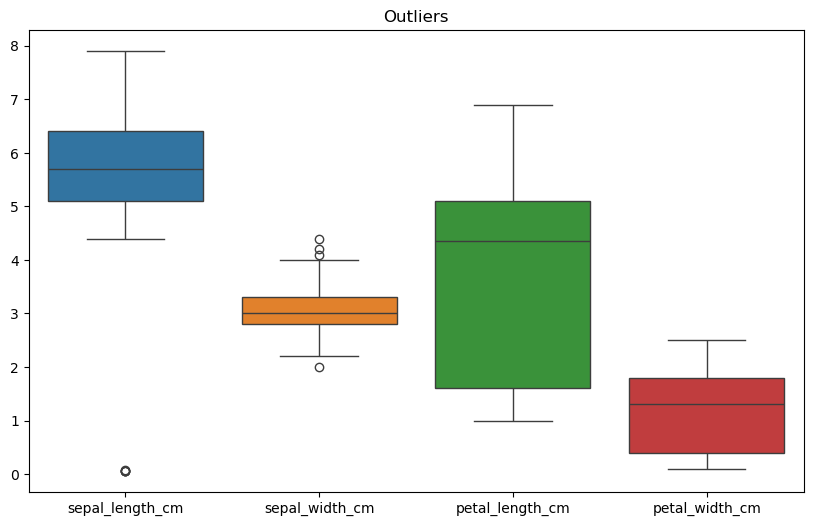

In [87]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.drop(columns=['class']))
plt.title("Outliers")
plt.show()

In [88]:
"""
Variables con outliers: 
sepal_length_cm 
sepal_width_cm
"""

'\nVariables con outliers: \nsepal_length_cm \nsepal_width_cm\n'

In [89]:
df['sepal_length_cm'].describe()

count    150.000000
mean       5.644627
std        1.312781
min        0.055000
25%        5.100000
50%        5.700000
75%        6.400000
max        7.900000
Name: sepal_length_cm, dtype: float64

In [90]:
#Outliers mediante IQR

Q1 = df['sepal_length_cm'].quantile(0.25)
Q3 = df['sepal_length_cm'].quantile(0.75)
IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

sepal_lenght_outliers = df[(df['sepal_length_cm'] < lower_bound) | (df['sepal_length_cm'] > upper_bound)]
print(sepal_lenght_outliers)


    sepal_length_cm  sepal_width_cm  petal_length_cm  petal_width_cm  \
77            0.067             3.0              5.0             1.7   
78            0.060             2.9              4.5             1.5   
79            0.057             2.6              3.5             1.0   
80            0.055             2.4              3.8             1.1   
81            0.055             2.4              3.7             1.0   

              class  
77  iris-versicolor  
78  iris-versicolor  
79  iris-versicolor  
80  iris-versicolor  
81  iris-versicolor  


In [91]:
#Elimino los outliers, muy cercanos a 0 y difere mucho con el df
df = df[(df['sepal_length_cm'] >= lower_bound) & (df['sepal_length_cm'] <= upper_bound)]


In [93]:
df['sepal_width_cm'].describe()

count    145.000000
mean       3.068276
std        0.431680
min        2.000000
25%        2.800000
50%        3.000000
75%        3.300000
max        4.400000
Name: sepal_width_cm, dtype: float64

In [94]:
#Outliers mediante IQR

Q1 = df['sepal_width_cm'].quantile(0.25)
Q3 = df['sepal_width_cm'].quantile(0.75)
IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

sepal_lenght_outliers = df[(df['sepal_width_cm'] < lower_bound) | (df['sepal_width_cm'] > upper_bound)]
print(sepal_lenght_outliers)

    sepal_length_cm  sepal_width_cm  petal_length_cm  petal_width_cm  \
15              5.7             4.4              1.5             0.4   
32              5.2             4.1              1.5             0.1   
33              5.5             4.2              1.4             0.2   
60              5.0             2.0              3.5             1.0   

              class  
15      iris-setosa  
32      iris-setosa  
33      iris-setosa  
60  iris-versicolor  


In [95]:
#Remplazo outliers con la mediana
mediana = df['sepal_width_cm'].median()
df.loc[(df['sepal_width_cm'] < lower_bound) | (df['sepal_width_cm'] > upper_bound), 'sepal_width_cm'] = mediana

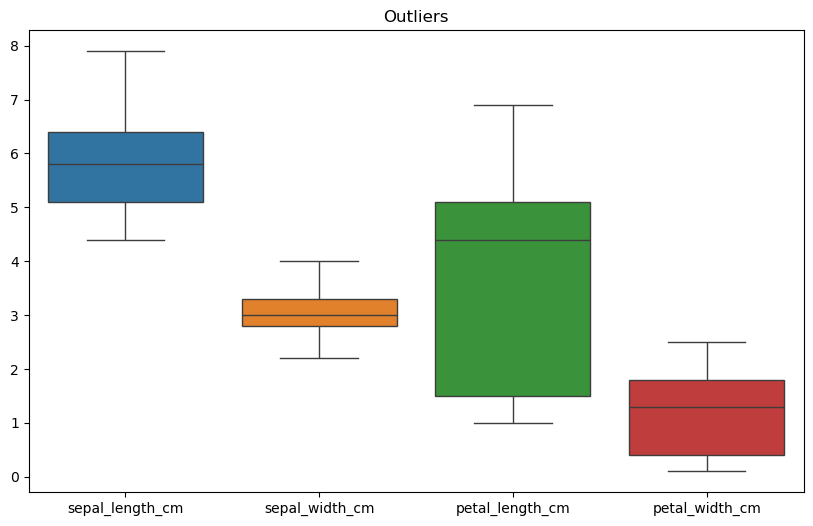

In [96]:
#Visual check de la eliminacion de outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.drop(columns=['class']))
plt.title("Outliers")
plt.show()

In [101]:
#Final data in .csv
df.to_csv('clean_iris-data.csv', index=False)
